# UAS Pengolahan Citra — Garbage Classification
**Mata Kuliah:** Pengolahan Citra / CS20-3403  
**Dataset:** Garbage Classification Dataset (Kaggle)  
**Algoritma:** CNN dengan Transfer Learning (MobileNetV2)  
**Kelas:** cardboard, glass, metal, paper, plastic, trash


## 📦 Install & Import Library

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('TensorFlow version:', tf.__version__)
print('Semua library berhasil diimport!')

c:\laragon\bin\python\python-3.10\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.1) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


TensorFlow version: 2.21.0
Semua library berhasil diimport!


## 📁 Soal 1 — Dataset dan Akuisisi Citra

**Nama Dataset:** Garbage Classification Dataset  
**Sumber:** Kaggle (https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification)  
**Tujuan:** Mengklasifikasikan sampah secara otomatis ke dalam 6 kategori  
**Jumlah Kelas:** 6 (cardboard, glass, metal, paper, plastic, trash)

In [2]:


DATASET_PATH = 'Trash_Dataset/images'
CLASSES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# Hitung jumlah gambar per kelas
print('='*50)
print('INFORMASI DATASET')
print('='*50)
total = 0
for cls in CLASSES:
    path = os.path.join(DATASET_PATH, cls)
    if os.path.exists(path):
        count = len(os.listdir(path))
        total += count
        print(f'  {cls:12s} : {count} gambar')
print(f'  {"TOTAL":12s} : {total} gambar')
print('='*50)

INFORMASI DATASET
  cardboard    : 2214 gambar
  glass        : 2500 gambar
  metal        : 2084 gambar
  paper        : 2315 gambar
  plastic      : 2288 gambar
  trash        : 2500 gambar
  TOTAL        : 13901 gambar


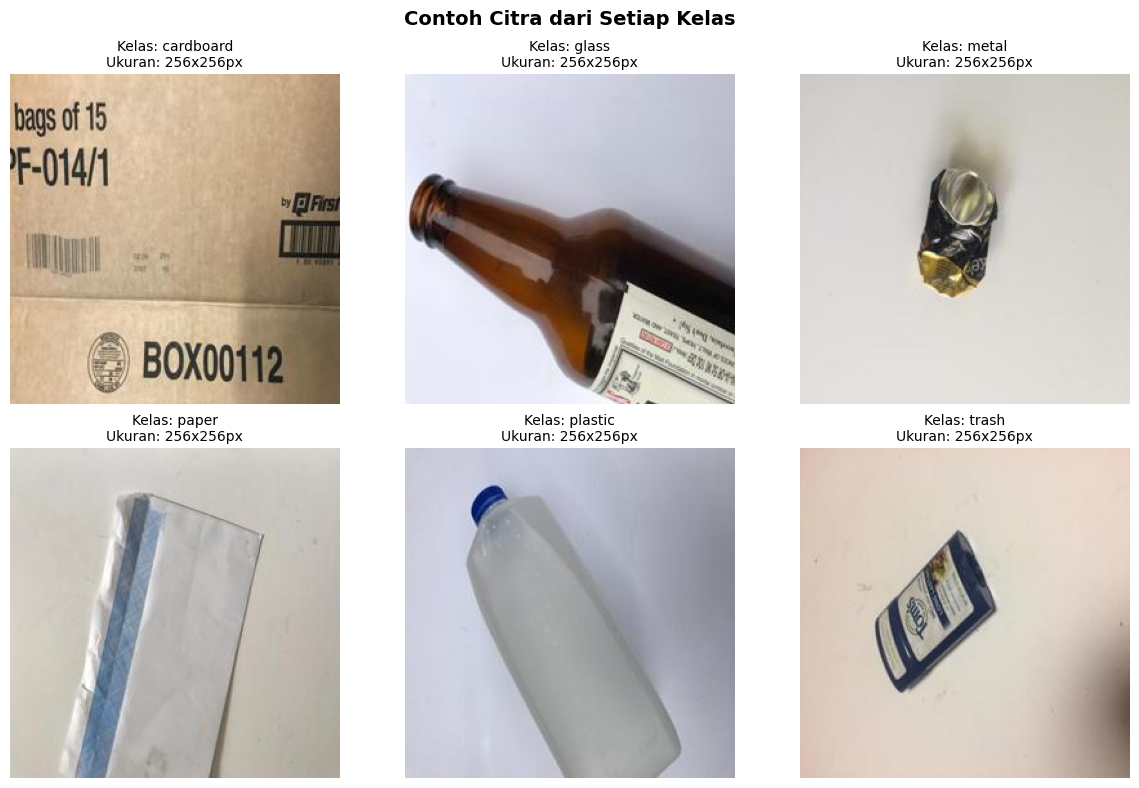

In [3]:
# Tampilkan contoh citra dari setiap kelas
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(CLASSES):
    cls_path = os.path.join(DATASET_PATH, cls)
    img_file = os.listdir(cls_path)[0]  # ambil gambar pertama
    img = cv2.imread(os.path.join(cls_path, img_file))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(f'Kelas: {cls}\nUkuran: {img.shape[1]}x{img.shape[0]}px', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Contoh Citra dari Setiap Kelas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🖼️ Soal 2 — Representasi Citra Digital

Pada bagian ini kita melihat bagaimana Python (OpenCV) membaca dan merepresentasikan citra secara digital.

In [4]:
# Ambil satu contoh gambar untuk demonstrasi
sample_cls = 'plastic'
sample_path = os.path.join(DATASET_PATH, sample_cls)
sample_file = os.path.join(sample_path, os.listdir(sample_path)[0])

# Baca gambar dengan OpenCV
img_bgr = cv2.imread(sample_file)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print('='*50)
print('REPRESENTASI CITRA DIGITAL')
print('='*50)
print(f'Tipe data      : {img_bgr.dtype}')       # uint8
print(f'Shape (HxWxC)  : {img_bgr.shape}')       # (tinggi, lebar, channel)
print(f'Tinggi         : {img_bgr.shape[0]} px')
print(f'Lebar          : {img_bgr.shape[1]} px')
print(f'Channel warna  : {img_bgr.shape[2]} (BGR)')
print(f'Nilai min-max  : {img_bgr.min()} - {img_bgr.max()}')
print(f'Format file    : {sample_file.split(".")[-1].upper()}')
print()
print('Contoh nilai pixel (10x10 pojok kiri atas, channel R):')
print(img_rgb[:5, :5, 0])  # channel R

REPRESENTASI CITRA DIGITAL
Tipe data      : uint8
Shape (HxWxC)  : (256, 256, 3)
Tinggi         : 256 px
Lebar          : 256 px
Channel warna  : 3 (BGR)
Nilai min-max  : 0 - 254
Format file    : JPG

Contoh nilai pixel (10x10 pojok kiri atas, channel R):
[[201 201 201 200 200]
 [201 201 201 200 200]
 [201 201 201 200 200]
 [201 201 201 200 200]
 [201 201 201 200 200]]


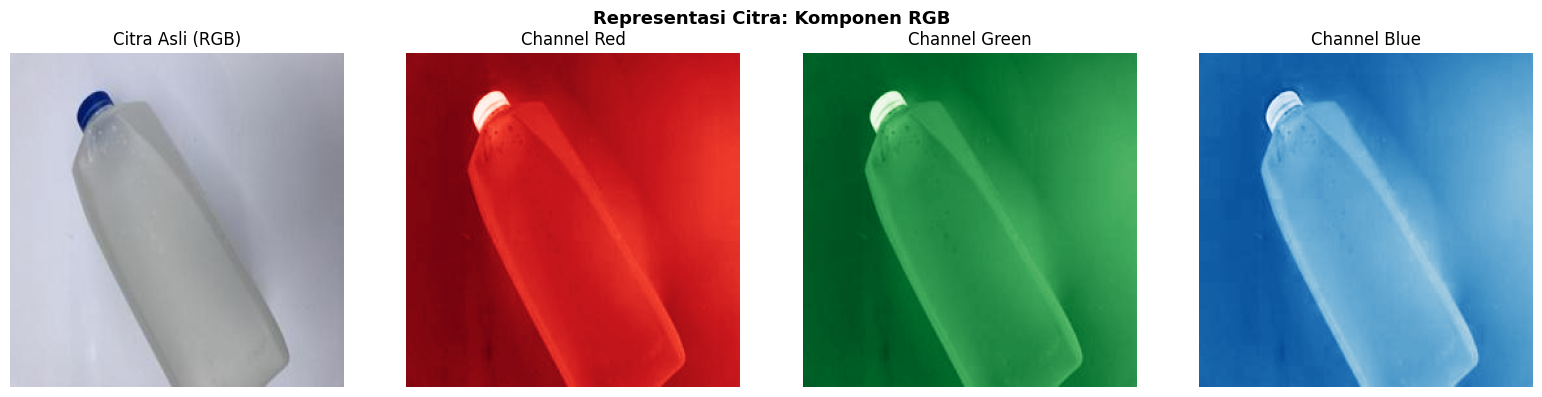

In [5]:
# Visualisasi channel RGB secara terpisah
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_rgb)
axes[0].set_title('Citra Asli (RGB)')
axes[0].axis('off')

channel_names = ['Red', 'Green', 'Blue']
cmaps = ['Reds', 'Greens', 'Blues']
for i in range(3):
    axes[i+1].imshow(img_rgb[:, :, i], cmap=cmaps[i])
    axes[i+1].set_title(f'Channel {channel_names[i]}')
    axes[i+1].axis('off')

plt.suptitle('Representasi Citra: Komponen RGB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## ⚙️ Soal 3 — Preprocessing / Teknik Pengolahan Citra

Berikut 7 tahapan preprocessing yang diterapkan pada dataset:

In [6]:
# ============================================
# PROSES 1: RESIZE
# Menyeragamkan ukuran semua citra agar bisa
# diproses oleh model CNN secara konsisten
# ============================================
IMG_SIZE = (224, 224)  # ukuran input MobileNetV2

img_resized = cv2.resize(img_rgb, IMG_SIZE)
print(f'[1] RESIZE: {img_rgb.shape[:2]} → {img_resized.shape[:2]}')

# ============================================
# PROSES 2: GRAYSCALE
# Mengubah citra berwarna menjadi citra abu-abu
# untuk reduksi dimensi dan analisis tekstur
# ============================================
img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
print(f'[2] GRAYSCALE: shape → {img_gray.shape}')

# ============================================
# PROSES 3: NORMALISASI PIXEL
# Mengubah nilai pixel dari 0-255 menjadi 0.0-1.0
# agar training model lebih stabil dan cepat konvergen
# ============================================
img_normalized = img_resized.astype('float32') / 255.0
print(f'[3] NORMALISASI: nilai pixel min={img_normalized.min():.2f}, max={img_normalized.max():.2f}')

# ============================================
# PROSES 4: GAUSSIAN BLUR (Filtering)
# Menghaluskan citra dan mengurangi noise
# menggunakan kernel Gaussian 5x5
# ============================================
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
print(f'[4] GAUSSIAN BLUR: kernel (5,5) diterapkan')

# ============================================
# PROSES 5: SEGMENTASI (Thresholding)
# Memisahkan objek dari latar belakang
# menggunakan metode Otsu's thresholding
# ============================================
_, img_thresh = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'[5] SEGMENTASI (Otsu): threshold diterapkan')

# ============================================
# PROSES 6: EDGE DETECTION (Canny)
# Mendeteksi tepi/kontur objek dalam citra
# untuk analisis bentuk objek sampah
# ============================================
img_edges = cv2.Canny(img_gray, threshold1=50, threshold2=150)
print(f'[6] CANNY EDGE DETECTION: threshold1=50, threshold2=150')

# ============================================
# PROSES 7: EKSTRAKSI FITUR (Histogram Warna)
# Mengekstrak distribusi warna dari citra
# sebagai representasi fitur untuk klasifikasi
# ============================================
hist_r = cv2.calcHist([img_resized], [0], None, [256], [0, 256])
hist_g = cv2.calcHist([img_resized], [1], None, [256], [0, 256])
hist_b = cv2.calcHist([img_resized], [2], None, [256], [0, 256])
print(f'[7] EKSTRAKSI FITUR (Histogram): histogram RGB diekstrak')

[1] RESIZE: (256, 256) → (224, 224)
[2] GRAYSCALE: shape → (224, 224)
[3] NORMALISASI: nilai pixel min=0.00, max=0.96
[4] GAUSSIAN BLUR: kernel (5,5) diterapkan
[5] SEGMENTASI (Otsu): threshold diterapkan
[6] CANNY EDGE DETECTION: threshold1=50, threshold2=150
[7] EKSTRAKSI FITUR (Histogram): histogram RGB diekstrak


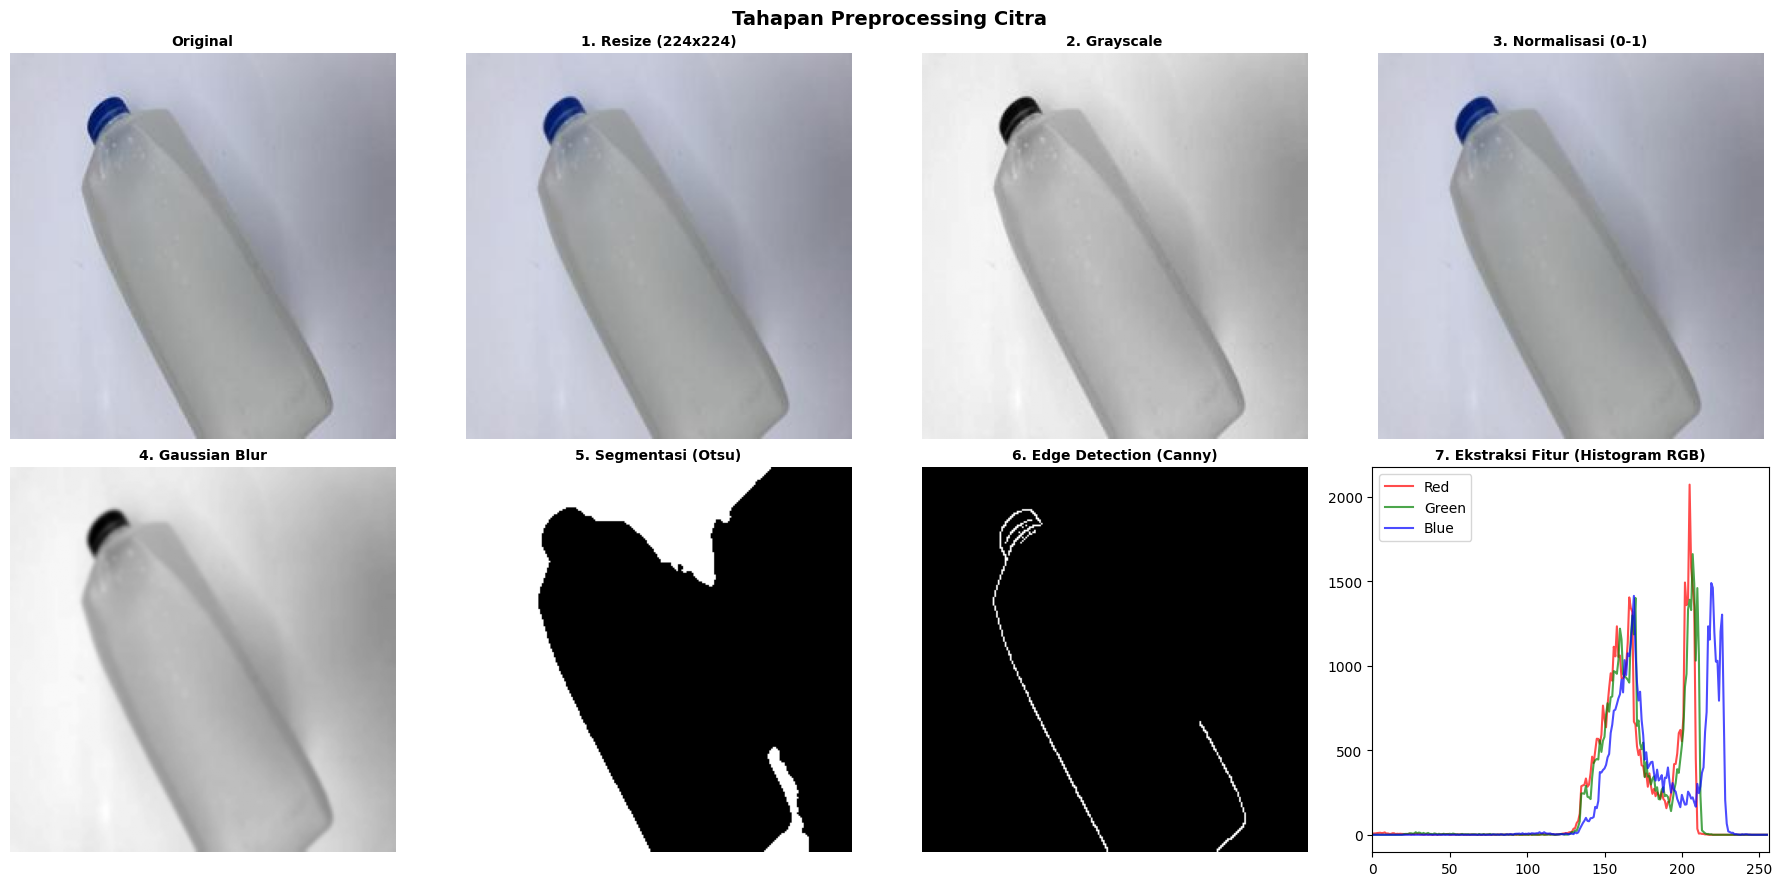

In [7]:
# Visualisasi semua tahap preprocessing
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

images = [
    (img_rgb,        'Original',               'viridis'),
    (img_resized,    '1. Resize (224x224)',     'viridis'),
    (img_gray,       '2. Grayscale',            'gray'),
    (img_normalized, '3. Normalisasi (0-1)',    'viridis'),
    (img_blur,       '4. Gaussian Blur',        'gray'),
    (img_thresh,     '5. Segmentasi (Otsu)',    'gray'),
    (img_edges,      '6. Edge Detection (Canny)','gray'),
]

for i, (img, title, cmap) in enumerate(images):
    if len(img.shape) == 3:
        axes[i].imshow(img)
    else:
        axes[i].imshow(img, cmap=cmap)
    axes[i].set_title(title, fontsize=10, fontweight='bold')
    axes[i].axis('off')

# Plot histogram warna di subplot terakhir
axes[7].plot(hist_r, color='red', label='Red', alpha=0.7)
axes[7].plot(hist_g, color='green', label='Green', alpha=0.7)
axes[7].plot(hist_b, color='blue', label='Blue', alpha=0.7)
axes[7].set_title('7. Ekstraksi Fitur (Histogram RGB)', fontsize=10, fontweight='bold')
axes[7].legend()
axes[7].set_xlim([0, 256])

plt.suptitle('Tahapan Preprocessing Citra', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🤖 Soal 4 — Implementasi CNN (MobileNetV2 Transfer Learning)

**Nama Algoritma:** Convolutional Neural Network (CNN) — MobileNetV2  
**Fungsi terhadap citra:** Mengekstrak fitur visual secara hierarkis (tepi → tekstur → bentuk → objek)  
**Hubungan dengan pengenalan objek:** CNN mengenali pola visual unik tiap jenis sampah untuk diklasifikasikan

In [8]:
# ============================================
# PERSIAPAN DATA DENGAN AUGMENTASI
# ============================================
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 20

# ImageDataGenerator dengan augmentasi untuk data training
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalisasi pixel
    rotation_range=20,        # rotasi acak ±20 derajat
    width_shift_range=0.2,    # geser horizontal
    height_shift_range=0.2,   # geser vertikal
    shear_range=0.2,          # shear transform
    zoom_range=0.2,           # zoom acak
    horizontal_flip=True,     # flip horizontal
    validation_split=0.2      # 20% untuk validasi
)

# Generator untuk data validasi (tanpa augmentasi)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Load data training
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Load data validasi
val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print('\nLabel kelas:', train_generator.class_indices)

Found 11123 images belonging to 6 classes.
Found 2778 images belonging to 6 classes.

Label kelas: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [9]:
# ============================================
# BANGUN MODEL CNN (MobileNetV2 + Custom Head)
# ============================================

# Load MobileNetV2 pre-trained (tanpa layer atas)
base_model = MobileNetV2(
    weights='imagenet',      # bobot pre-trained ImageNet
    include_top=False,       # tanpa fully connected layer asli
    input_shape=(224, 224, 3)
)

# Freeze base model (tidak ditraining ulang)
base_model.trainable = False

# Tambahkan custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)      # pooling global
x = Dense(256, activation='relu')(x)  # fully connected layer
x = Dropout(0.5)(x)                   # dropout untuk regularisasi
output = Dense(6, activation='softmax')(x)  # output 6 kelas

model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Arsitektur Model:')
print(f'  - Base: MobileNetV2 (pre-trained ImageNet)')
print(f'  - GlobalAveragePooling2D')
print(f'  - Dense(256, relu)')
print(f'  - Dropout(0.5)')
print(f'  - Dense(6, softmax)  ← output 6 kelas')
print(f'\nTotal parameter: {model.count_params():,}')

Arsitektur Model:
  - Base: MobileNetV2 (pre-trained ImageNet)
  - GlobalAveragePooling2D
  - Dense(256, relu)
  - Dropout(0.5)
  - Dense(6, softmax)  ← output 6 kelas

Total parameter: 2,587,462


In [10]:
# ============================================
# TRAINING MODEL
# ============================================

# Callback untuk early stopping dan learning rate scheduler
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

print('Mulai training...')
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print('\nTraining selesai!')

Mulai training...
Epoch 1/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 691s 2s/step - accuracy: 0.7147 - loss: 0.7774 - val_accuracy: 0.8081 - val_loss: 0.5564 - learning_rate: 0.0010
Epoch 2/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - accuracy: 0.8049 - loss: 0.5407 - val_accuracy: 0.8222 - val_loss: 0.5039 - learning_rate: 0.0010
Epoch 3/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.8218 - loss: 0.4919 - val_accuracy: 0.8441 - val_loss: 0.4446 - learning_rate: 0.0010
Epoch 4/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 362s 1s/step - accuracy: 0.8354 - loss: 0.4487 - val_accuracy: 0.8553 - val_loss: 0.4311 - learning_rate: 0.0010
Epoch 5/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 362s 1s/step - accuracy: 0.8464 - loss: 0.4237 - val_accuracy: 0.8679 - val_loss: 0.3814 - learning_rate: 0.0010
Epoch 6/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 374s 1s/step - accuracy: 0.8545 - loss: 0.4003 - val_accuracy: 0.8701 - val_loss: 0.3861 - learning_rate: 0.0010
Epoch 7/20
348/348 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy:

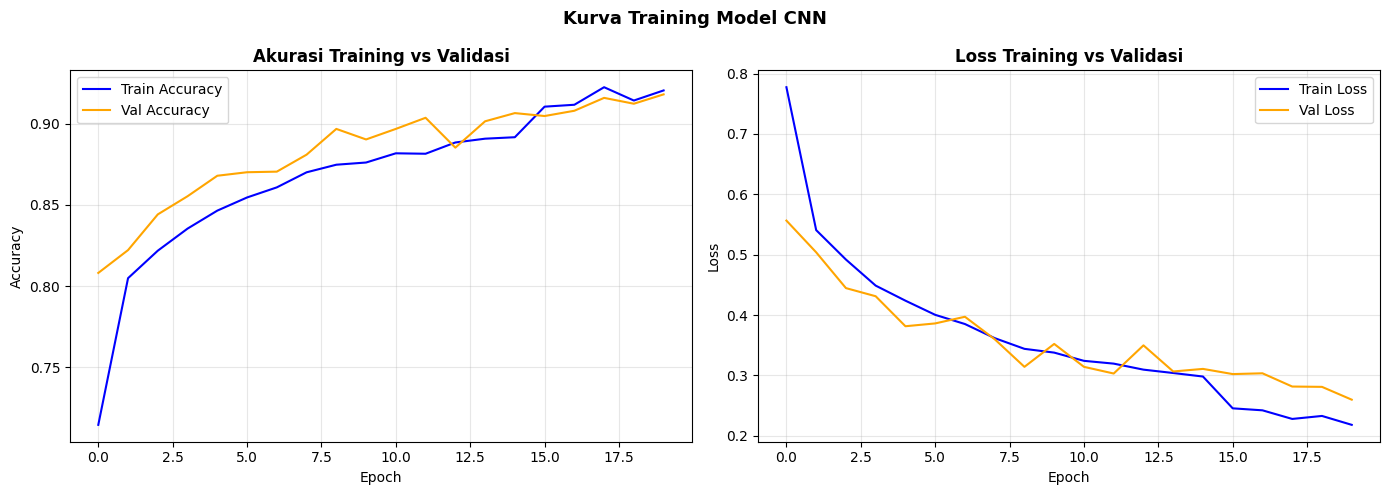

In [11]:
# Visualisasi kurva training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Akurasi Training vs Validasi', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Loss Training vs Validasi', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Kurva Training Model CNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Soal 5 — Analisis Hasil

In [12]:
# ============================================
# EVALUASI MODEL
# ============================================

# Evaluasi pada data validasi
val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)
print('='*50)
print('HASIL EVALUASI MODEL')
print('='*50)
print(f'Validation Loss     : {val_loss:.4f}')
print(f'Validation Accuracy : {val_accuracy*100:.2f}%')
print('='*50)

HASIL EVALUASI MODEL
Validation Loss     : 0.2597
Validation Accuracy : 91.79%


In [13]:
# Classification Report & Confusion Matrix
val_generator.reset()
y_pred_probs = model.predict(val_generator, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

   cardboard       0.94      0.93      0.94       442
       glass       0.93      0.89      0.91       500
       metal       0.88      0.97      0.93       416
       paper       0.91      0.95      0.93       463
     plastic       0.91      0.91      0.91       457
       trash       0.94      0.86      0.90       500

    accuracy                           0.92      2778
   macro avg       0.92      0.92      0.92      2778
weighted avg       0.92      0.92      0.92      2778



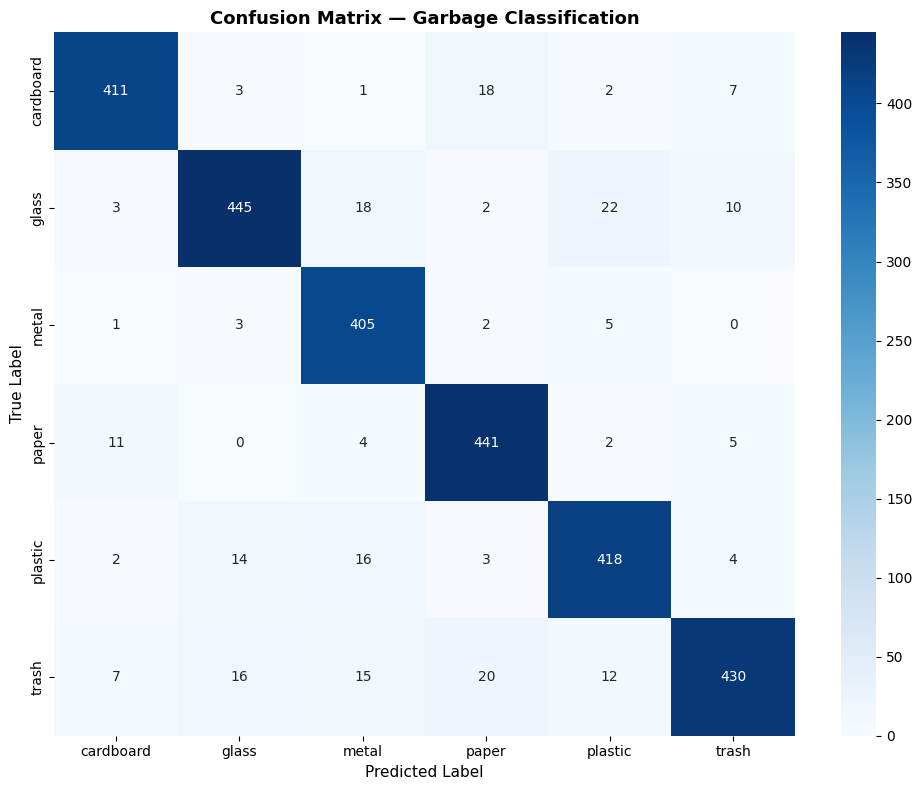

In [14]:
# Visualisasi Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — Garbage Classification', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.tight_layout()
plt.show()

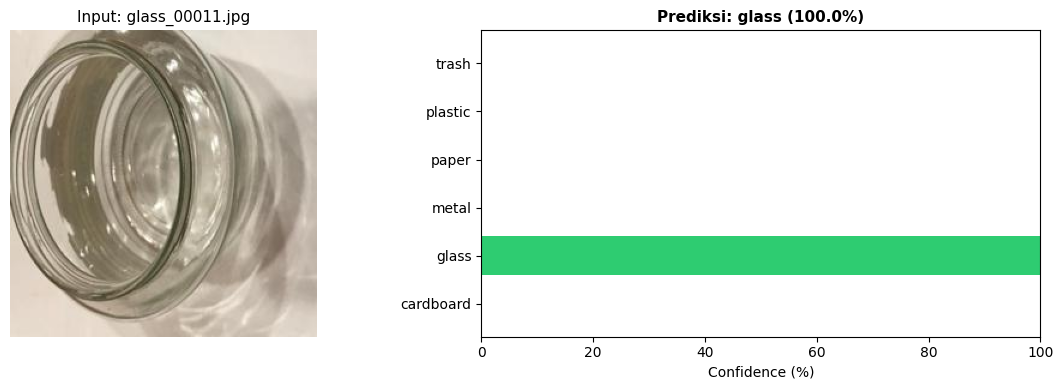


Hasil Prediksi : glass
Confidence     : 99.99%
Label Asli     : glass
Prediksi Benar : True


In [15]:
# ============================================
# UJI PREDIKSI PADA GAMBAR BARU
# ============================================

def predict_image(img_path, model, class_names, img_size=(224, 224)):
    """Prediksi kelas sampah dari satu gambar"""
    # Baca dan preprocessing gambar
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, img_size)
    img_norm = img_resized.astype('float32') / 255.0
    img_batch = np.expand_dims(img_norm, axis=0)  # tambah dimensi batch

    # Prediksi
    preds = model.predict(img_batch, verbose=0)[0]
    pred_class = class_names[np.argmax(preds)]
    confidence = np.max(preds) * 100

    # Tampilkan hasil
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Input: {os.path.basename(img_path)}', fontsize=11)
    axes[0].axis('off')

    colors = ['#2ecc71' if c == pred_class else '#bdc3c7' for c in class_names]
    axes[1].barh(class_names, preds * 100, color=colors)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title(f'Prediksi: {pred_class} ({confidence:.1f}%)', fontsize=11, fontweight='bold')
    axes[1].set_xlim([0, 100])

    plt.tight_layout()
    plt.show()

    return pred_class, confidence

# Uji prediksi dengan gambar sample
test_cls = 'glass'
test_path = os.path.join(DATASET_PATH, test_cls)
test_img  = os.path.join(test_path, os.listdir(test_path)[5])  # gambar ke-6

pred_class, confidence = predict_image(test_img, model, class_names)
print(f'\nHasil Prediksi : {pred_class}')
print(f'Confidence     : {confidence:.2f}%')
print(f'Label Asli     : {test_cls}')
print(f'Prediksi Benar : {pred_class == test_cls}')

In [16]:
# ============================================
# KESIMPULAN
# ============================================
print('='*60)
print('KESIMPULAN ANALISIS HASIL')
print('='*60)
print(f'1. Dataset  : Garbage Classification (6 kelas sampah)')
print(f'2. Model    : CNN MobileNetV2 (Transfer Learning)')
print(f'3. Akurasi  : {val_accuracy*100:.2f}%')
print()
if val_accuracy >= 0.85:
    print('✅ Model BERHASIL melakukan pengolahan citra dengan baik.')
    print('   Akurasi ≥ 85% menunjukkan model mampu membedakan')
    print('   jenis sampah dengan sangat baik.')
elif val_accuracy >= 0.70:
    print('⚠️  Model CUKUP BAIK namun masih bisa ditingkatkan.')
    print('   Akurasi 70-84% menunjukkan model cukup mampu')
    print('   membedakan jenis sampah.')
else:
    print('❌ Model perlu perbaikan lebih lanjut.')
    print('   Coba tingkatkan epochs atau gunakan fine-tuning.')
print('='*60)

KESIMPULAN ANALISIS HASIL
1. Dataset  : Garbage Classification (6 kelas sampah)
2. Model    : CNN MobileNetV2 (Transfer Learning)
3. Akurasi  : 91.79%

✅ Model BERHASIL melakukan pengolahan citra dengan baik.
   Akurasi ≥ 85% menunjukkan model mampu membedakan
   jenis sampah dengan sangat baik.


In [18]:
# Simpan model (opsional)
model.save('content/garbage_classifier_mobilenetv2.h5')
print('Model disimpan: garbage_classifier_mobilenetv2.h5')

Model disimpan: garbage_classifier_mobilenetv2.h5


In [19]:
model.save('garbage_classifier_mobilenetv2.keras')
print('Berhasil')

Berhasil
